In [511]:
import sys
import matplotlib.pyplot as plt
import json

In [512]:
sys.path.append('../')
sys.path

['e:\\dev\\python\\Python314\\python314.zip',
 'e:\\dev\\python\\Python314\\DLLs',
 'e:\\dev\\python\\Python314\\Lib',
 'e:\\dev\\python\\Python314',
 '',
 'C:\\Users\\LOQ\\AppData\\Roaming\\Python\\Python314\\site-packages',
 'e:\\dev\\python\\Python314\\Lib\\site-packages',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '../',
 '.

In [513]:
from src.utils import Checkpointer

In [514]:
to_plot = [
    "20260424_182648",
    "20260424_185039",
    "20260424_180435",
    "20260424_193414"
]

metrics = ["accuracy", "f1_score", "auc", "train_loss", "val_loss"]

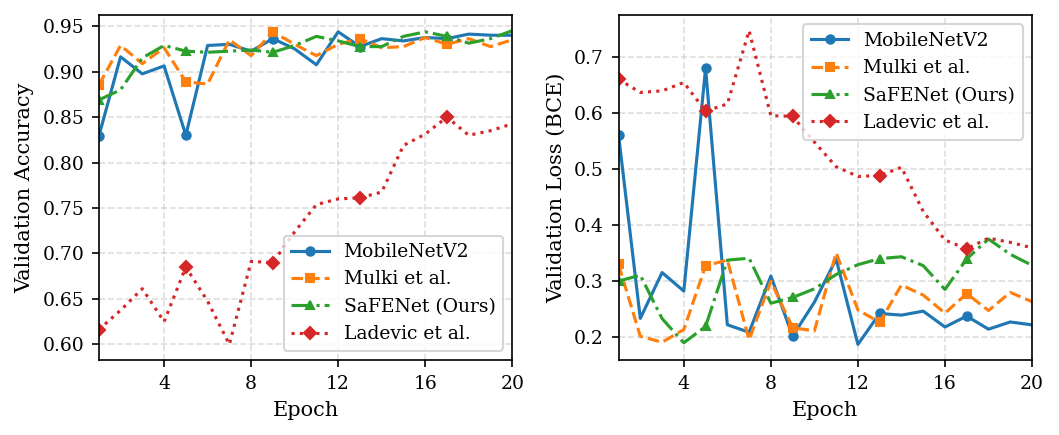

Saved → paper/val_curves.pdf + paper/val_curves.png


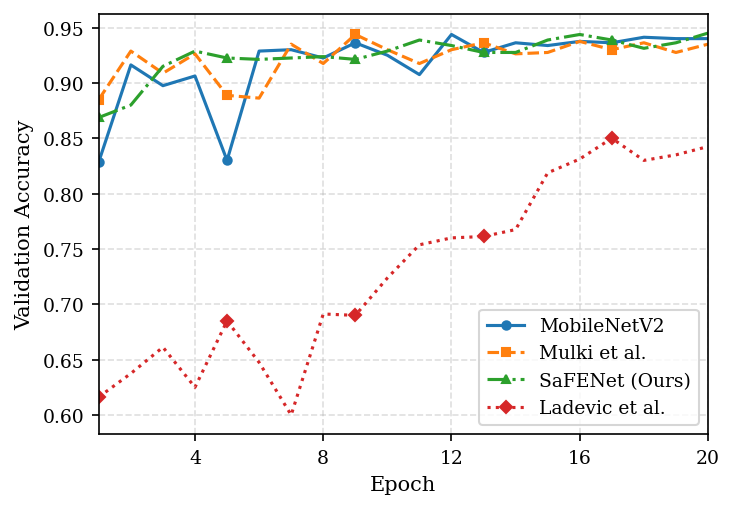

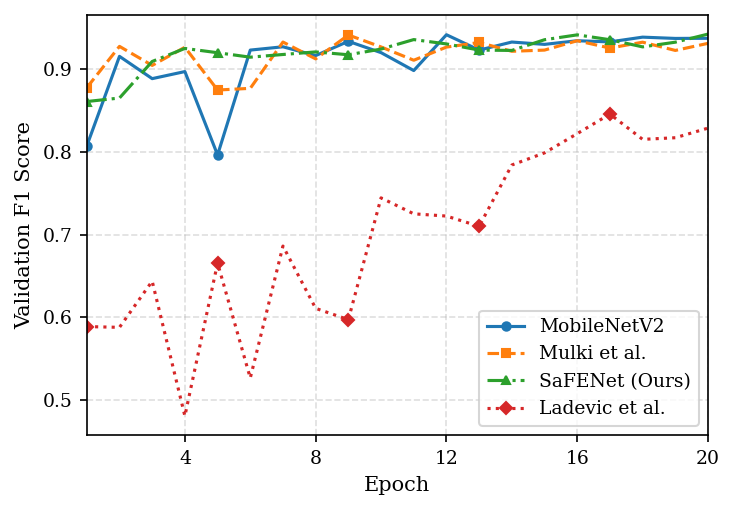

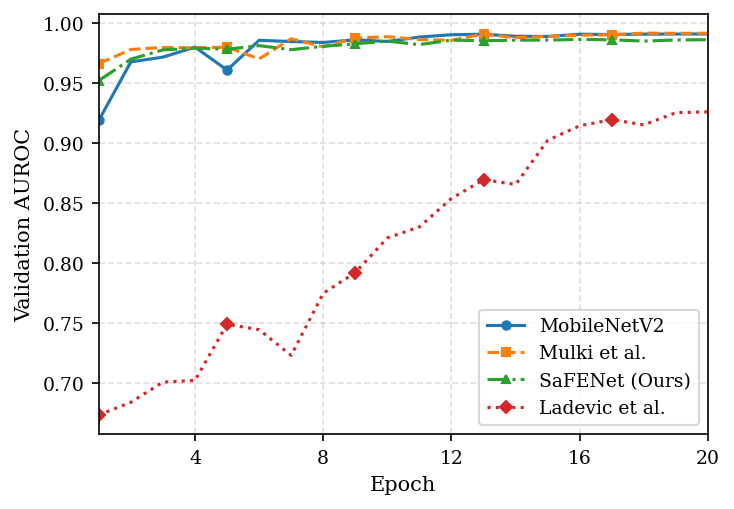

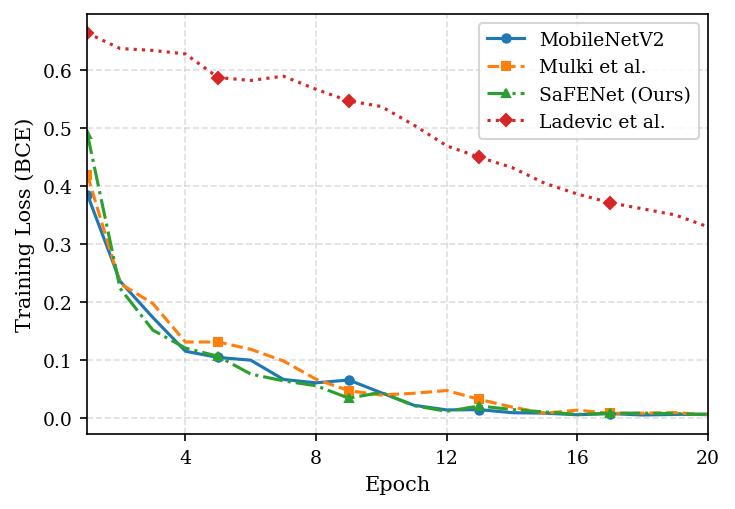

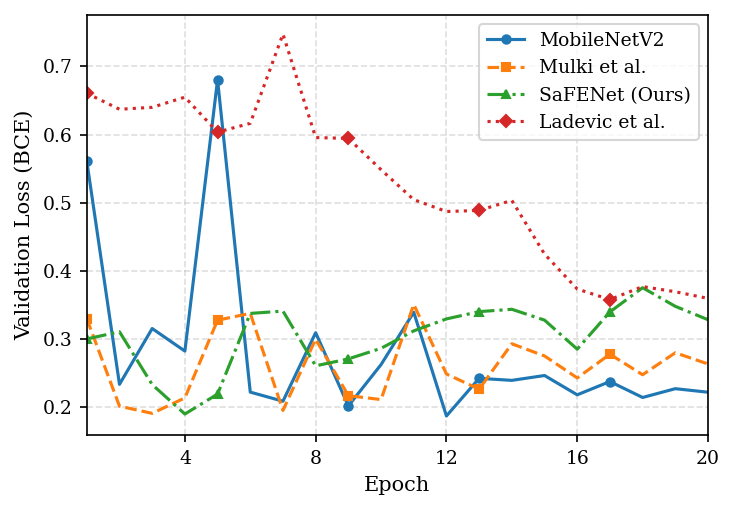

In [515]:
import matplotlib.ticker as mticker

# ── Paper-quality rcParams ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'serif',
    'font.size':       10,
    'axes.titlesize':  11,
    'axes.labelsize':  10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi':      150,
    'savefig.dpi':     300,
    'axes.grid':       True,
    'grid.linestyle':  '--',
    'grid.alpha':      0.4,
    'lines.linewidth': 1.5,
})

# Human-readable model names for legend
MODEL_LABELS = {
    'safenet':     'SaFENet (Ours)',
    'mobilenetv2': 'MobileNetV2',
    'mulki':       'Mulki et al.',
    'ladevic':     'Ladevic et al.',
}

# Distinct styles so figures survive greyscale printing
STYLES = [
    {'color': '#1f77b4', 'linestyle': '-',   'marker': 'o', 'markevery': 4, 'markersize': 4},
    {'color': '#ff7f0e', 'linestyle': '--',  'marker': 's', 'markevery': 4, 'markersize': 4},
    {'color': '#2ca02c', 'linestyle': '-.',  'marker': '^', 'markevery': 4, 'markersize': 4},
    {'color': '#d62728', 'linestyle': ':',   'marker': 'D', 'markevery': 4, 'markersize': 4},
]

to_plot = [
    "20260424_182648",   # mobilenetv2
    "20260424_185039",   # mulki
    "20260424_180435",   # safenet
    "20260424_193414",   # ladevic
]

# Load once, reuse across all plots
all_metrics = {
    id_: Checkpointer.load_metrics(f'../checkpoints/{id_}')
    for id_ in to_plot
}
epochs = range(1, 21)

# ── Paper figure: val accuracy + val loss side by side ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.0))   # 7.16 in = IEEE double-column width

for ax, (metric_key, ylabel) in zip(axes, [
    ('accuracy', 'Validation Accuracy'),
    ('val_loss',  'Validation Loss (BCE)'),
]):
    for id_, style in zip(to_plot, STYLES):
        m = all_metrics[id_]
        label = MODEL_LABELS.get(m['config']['model'], m['config']['model'])
        ax.plot(epochs, m[metric_key], label=label, **style)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, 20)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    ax.legend(loc='best')

fig.tight_layout()
fig.savefig('../paper/val_curves.pdf', bbox_inches='tight')
fig.savefig('../paper/val_curves.png', bbox_inches='tight')
plt.show()
print("Saved → paper/val_curves.pdf + paper/val_curves.png")

# ── Individual exploratory plots for all metrics ──────────────────────────────
METRIC_LABELS = {
    'accuracy':   'Validation Accuracy',
    'f1_score':   'Validation F1 Score',
    'auc':        'Validation AUROC',
    'train_loss': 'Training Loss (BCE)',
    'val_loss':   'Validation Loss (BCE)',
}

for metric_key, ylabel in METRIC_LABELS.items():
    fig, ax = plt.subplots(figsize=(5, 3.5))
    for id_, style in zip(to_plot, STYLES):
        m = all_metrics[id_]
        label = MODEL_LABELS.get(m['config']['model'], m['config']['model'])
        ax.plot(epochs, m[metric_key], label=label, **style)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, 20)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    ax.legend(loc='best')
    fig.tight_layout()
    plt.show()